In [1]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
np.random.seed(42)

num_records = 100

states = ["Low Demand", "Medium Demand", "High Demand"]
actions = ["Increase Price", "Decrease Price", "Keep Price"]
next_states = ["Low Demand", "Medium Demand", "High Demand"]

transitions = pd.DataFrame({
    "Current_State": np.random.choice(states, num_records),
    "Action": np.random.choice(actions, num_records),
    "Reward": np.random.randint(-20, 100, num_records),
    "Next_State": np.random.choice(next_states, num_records)
})

transitions.head()

,Current_State,Action,Reward,Next_State
0,High Demand,Keep Price,31,Low Demand
1,Low Demand,Keep Price,92,Low Demand
2,High Demand,Keep Price,41,High Demand
3,High Demand,Increase Price,92,High Demand
4,Low Demand,Keep Price,37,High Demand


In [3]:
transitions.to_csv("state_action_transitions.csv", index=False)

print("State-Action transition dataset created successfully!")

State-Action transition dataset created successfully!


In [4]:
df = pd.read_csv("state_action_transitions.csv")

df.head()

,Current_State,Action,Reward,Next_State
0,High Demand,Keep Price,31,Low Demand
1,Low Demand,Keep Price,92,Low Demand
2,High Demand,Keep Price,41,High Demand
3,High Demand,Increase Price,92,High Demand
4,Low Demand,Keep Price,37,High Demand


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Current_State  100 non-null    object
 1   Action         100 non-null    object
 2   Reward         100 non-null    int64 
 3   Next_State     100 non-null    object
dtypes: int64(1), object(3)
memory usage: 3.3+ KB


## Observation

The dataset contains four columns:

- Current_State
- Action
- Reward
- Next_State

Each row represents one interaction between the RL agent and the environment.

In [6]:
df.isnull().sum()

,0
Current_State,0
Action,0
Reward,0
Next_State,0


## Observation

No missing values were found in the transition dataset.

In [7]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 2


In [8]:
print("Current States:")
print(df["Current_State"].unique())

print("\nNext States:")
print(df["Next_State"].unique())

Current States:
['High Demand' 'Low Demand' 'Medium Demand']

Next States:
['Low Demand' 'High Demand' 'Medium Demand']


In [9]:
print(df["Action"].unique())

['Keep Price' 'Increase Price' 'Decrease Price']


## Observation

The environment supports three actions:

- Increase Price
- Decrease Price
- Keep Price

In [10]:
df["Reward"].describe()

,Reward
count,100.000000
mean,37.960000
std,36.685923
min,-20.000000
25%,8.250000
50%,37.500000
75%,71.000000
max,98.000000


## Observation

The reward values contain both positive and negative values, representing successful and unsuccessful pricing decisions.

In [11]:
transition_counts = df.groupby(
    ["Current_State", "Action", "Next_State"]
).size().reset_index(name="Count")

transition_counts

,Current_State,Action,Next_State,Count
0,High Demand,Decrease Price,High Demand,4
1,High Demand,Decrease Price,Low Demand,2
2,High Demand,Decrease Price,Medium Demand,1
3,High Demand,Increase Price,High Demand,2
4,High Demand,Increase Price,Low Demand,5
5,High Demand,Increase Price,Medium Demand,3
6,High Demand,Keep Price,High Demand,6
7,High Demand,Keep Price,Low Demand,3
8,High Demand,Keep Price,Medium Demand,5
9,Low Demand,Decrease Price,High Demand,2


In [12]:
df["Action"].value_counts()

,count
Action,
Keep Price,42
Increase Price,33
Decrease Price,25


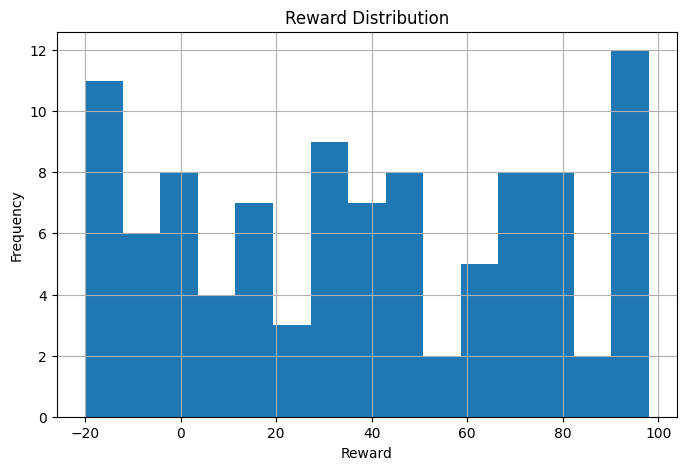

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Reward"], bins=15)

plt.title("Reward Distribution")

plt.xlabel("Reward")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

## Observation

The histogram shows the distribution of rewards obtained after different actions.

# State-Action Verification

The transition dataset confirms that:

- Every current state has an associated action.
- Every action results in a reward.
- Every action leads to a next state.

This verifies the expected interaction cycle of the Reinforcement Learning environment.

Current State
↓

Action
↓

Reward
↓

Next State

# Summary

The simulated state-action transition dataset was successfully validated.

Validation included:

- Dataset verification
- Missing value check
- Duplicate check
- State verification
- Action verification
- Reward analysis
- Transition count analysis

The transition data follows the expected Reinforcement Learning interaction structure and can be used for testing and documentation purposes.

**Note:** This dataset contains simulated transitions created for validation. It should be replaced with actual RL environment transitions when the trained agent is available.